# 4.0 Methodology & Analysis

This notebook builds a match-level World Cup outcome predictor from player-aggregated club statistics. The modeling unit is a single World Cup match, with the target being win, draw, or loss from the home team's perspective. Features are expressed as pairwise differentials between opposing squads.

## 4.1 Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

POS_COLORS = {"FW": "#D85A30", "MF": "#3266ad", "DF": "#1D9E75", "GK": "#BA7517"}

## 4.2 Build Match-Level Feature Matrix

### 4.2.1 Load & Aggregate

In [ ]:
# Load cleaned player data
df = pd.read_csv("player_stats.csv")

# Rejoin WC stats
roster = pd.read_csv("player_rosters.csv")
wc_cols = [
    "key_id",
    "matches_played",
    "starts",
    "sub_appearances",
    "goals",
    "own_goals",
    "penalty_goals",
    "yellow_cards",
    "red_cards",
    "second_yellows",
    "times_subbed_off",
    "awards_won",
]
roster_wc = roster[wc_cols].rename(
    columns={
        "goals": "wc_goals",
        "own_goals": "wc_own_goals",
        "penalty_goals": "wc_penalty_goals",
        "yellow_cards": "wc_yellow_cards",
        "red_cards": "wc_red_cards",
        "second_yellows": "wc_second_yellows",
    }
)
df = df.merge(roster_wc, on="key_id", how="left")

# Load matches + Elo
matches = pd.read_csv("match_features_base.csv")
elo = pd.read_csv("elo_ratings.csv")

active = df[df["has_stats"] == True].copy()
wc_matches = matches[matches["tournament_id"].str.startswith("WC-")].copy()

WC_YEAR = {
    "WC-2006": 2006,
    "WC-2010": 2010,
    "WC-2014": 2014,
    "WC-2018": 2018,
    "WC-2022": 2022,
}
TEAM_NAME_FIX = {"Czech Republic": "Czechia", "Serbia and Montenegro": "Serbia"}

print(f"Active players: {active.shape}")
print(f"WC matches: {wc_matches.shape}")

Active players: (2663, 52)
WC matches: (488, 35)


In [ ]:
# ── Appearance-weighted squad aggregation ───────────────────────────────────
def weighted_mean(group, col, weight_col="total_appearances"):
    w = group[weight_col].fillna(0)
    v = group[col].fillna(0)
    if w.sum() == 0:
        return np.nan
    return np.average(v, weights=w)


team_features = []
for (wc, team), grp in active.groupby(["wc_tournament", "national_team"]):
    row = {"wc_tournament": wc, "national_team": team}

    # Positional market values (keep these, drop squad_avg_mv)
    for pos in ["FW", "MF", "DF"]:
        pg = grp[grp["position_code"] == pos]
        row[f"{pos}_avg_mv"] = pg["market_value"].mean() if len(pg) > 0 else np.nan
        row[f"{pos}_avg_goals_per_app"] = (
            weighted_mean(pg, "goals_per_app") if len(pg) > 0 else np.nan
        )
        row[f"{pos}_avg_assists_per_app"] = (
            weighted_mean(pg, "assists_per_app") if len(pg) > 0 else np.nan
        )

    # GK
    gk = grp[grp["position_code"] == "GK"]
    row["GK_avg_clean_sheet_rate"] = (
        weighted_mean(gk, "clean_sheet_rate") if len(gk) > 0 else np.nan
    )

    # Squad-wide
    row["squad_assists_per_app"] = weighted_mean(grp, "assists_per_app")
    row["squad_goals_per_app"] = weighted_mean(grp, "goals_per_app")
    row["squad_avg_club_pos"] = grp["club_league_position"].mean()
    row["squad_clean_sheet_rate"] = weighted_mean(grp, "clean_sheet_rate")
    row["squad_mv_cv"] = (
        grp["market_value"].std() / grp["market_value"].mean()
        if grp["market_value"].mean() > 0
        else np.nan
    )

    team_features.append(row)

team_df = pd.DataFrame(team_features)

# Add Elo
team_df["wc_year"] = team_df["wc_tournament"].map(WC_YEAR)
team_df["elo_team"] = team_df["national_team"].replace(TEAM_NAME_FIX)
elo_merge = elo[["year", "team", "rating"]].rename(
    columns={"year": "wc_year", "team": "elo_team", "rating": "elo_rating"}
)
team_df = team_df.merge(elo_merge, on=["wc_year", "elo_team"], how="left")

print(f"Team features: {team_df.shape}")
print(f"Elo coverage: {team_df['elo_rating'].notna().sum()}/{len(team_df)}")

Team features: (158, 20)
Elo coverage: 158/158


### 4.2.2 Compute Pairwise Differentials

In [ ]:
DIFF_FEATURES = [
    "elo_rating",
    "FW_avg_mv",
    "MF_avg_mv",
    "DF_avg_mv",
    "FW_avg_goals_per_app",
    "MF_avg_assists_per_app",
    "squad_assists_per_app",
    "squad_goals_per_app",
    "squad_avg_club_pos",
    "squad_clean_sheet_rate",
    "GK_avg_clean_sheet_rate",
    "squad_mv_cv",
]


def build_match_matrix(match_df, team_df, features):
    rows = []
    for _, m in match_df.iterrows():
        wc = m["tournament_id"]
        home = m["team_name_home"]
        away = m["team_name_away"]

        home_row = team_df[
            (team_df["wc_tournament"] == wc) & (team_df["national_team"] == home)
        ]
        away_row = team_df[
            (team_df["wc_tournament"] == wc) & (team_df["national_team"] == away)
        ]

        if len(home_row) == 0 or len(away_row) == 0:
            continue

        row = {
            "match_id": m["match_id"],
            "wc_tournament": wc,
            "wc_year": WC_YEAR.get(wc, 0),
            "home_team": home,
            "away_team": away,
            "goal_diff": m["goals_for_home"] - m["goals_for_away"],
            "result": m["result_home"],
            "stage": m["stage_name"],
            "knockout": m["knockout_stage"],
        }

        for feat in features:
            h = home_row.iloc[0].get(feat, np.nan)
            a = away_row.iloc[0].get(feat, np.nan)
            row[f"diff_{feat}"] = h - a if pd.notna(h) and pd.notna(a) else np.nan

        rows.append(row)

    return pd.DataFrame(rows)


match_df = build_match_matrix(wc_matches, team_df, DIFF_FEATURES)

# Encode target: W=2, D=1, L=0
RESULT_MAP = {"W": 2, "D": 1, "L": 0}
match_df["result_enc"] = match_df["result"].map(RESULT_MAP)

print(f"Match matrix: {match_df.shape}")
print(f"\nResult distribution:")
print(match_df["result"].value_counts())
print(f"\nMissing values per feature:")
diff_cols = [c for c in match_df.columns if c.startswith("diff_")]
print(match_df[diff_cols].isna().sum().to_string())

Match matrix: (314, 22)

Result distribution:
result
W    146
L    116
D     52
Name: count, dtype: int64

Missing values per feature:
diff_elo_rating                  0
diff_FW_avg_mv                   7
diff_MF_avg_mv                   9
diff_DF_avg_mv                   6
diff_FW_avg_goals_per_app        7
diff_MF_avg_assists_per_app      9
diff_squad_assists_per_app       0
diff_squad_goals_per_app         0
diff_squad_avg_club_pos          6
diff_squad_clean_sheet_rate      0
diff_GK_avg_clean_sheet_rate    74
diff_squad_mv_cv                 6


### 4.2.3 Multicollinearity Check (VIF)

In [ ]:
# Drop rows with any NaN in features
feat_cols = [c for c in match_df.columns if c.startswith("diff_")]
clean = match_df[feat_cols + ["result_enc", "wc_year"]].dropna().copy()

print(f"Clean rows (no NaN): {len(clean)}/{len(match_df)}")

# Standardize for VIF
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clean[feat_cols])

vif_data = pd.DataFrame(
    {
        "Feature": [c.replace("diff_", "") for c in feat_cols],
        "VIF": [
            variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])
        ],
    }
).sort_values("VIF", ascending=False)

print("\n=== Variance Inflation Factors ===")
print(vif_data.to_string(index=False))
print(f"\nFeatures with VIF > 5: {(vif_data['VIF'] > 5).sum()}")

Clean rows (no NaN): 240/314

=== Variance Inflation Factors ===
                Feature      VIF
              MF_avg_mv 5.316560
              DF_avg_mv 4.945597
  squad_assists_per_app 3.880896
              FW_avg_mv 3.420742
    squad_goals_per_app 2.815926
             elo_rating 2.798549
     squad_avg_club_pos 2.632425
 MF_avg_assists_per_app 2.582661
   FW_avg_goals_per_app 1.992982
            squad_mv_cv 1.723472
 squad_clean_sheet_rate 1.584060
GK_avg_clean_sheet_rate 1.145046

Features with VIF > 5: 1


In [ ]:
# Drop features with VIF > 5, iteratively
feat_cols_final = feat_cols.copy()
dropped = []

while True:
    X_scaled = scaler.fit_transform(clean[feat_cols_final])
    vifs = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
    vif_df = pd.DataFrame({"Feature": feat_cols_final, "VIF": vifs})
    max_vif = vif_df["VIF"].max()

    if max_vif <= 5:
        break

    worst = vif_df.loc[vif_df["VIF"].idxmax(), "Feature"]
    feat_cols_final.remove(worst)
    dropped.append(worst)
    print(f"Dropped {worst} (VIF={max_vif:.1f})")

print(f"\nDropped features: {dropped}")
print(f"Remaining features ({len(feat_cols_final)}):")
for f in feat_cols_final:
    print(f"  {f.replace('diff_', '')}")

# Final VIF check
X_scaled = scaler.fit_transform(clean[feat_cols_final])
vif_final = pd.DataFrame(
    {
        "Feature": [c.replace("diff_", "") for c in feat_cols_final],
        "VIF": [
            variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])
        ],
    }
).sort_values("VIF", ascending=False)
print(f"\n=== Final VIF ===")
print(vif_final.to_string(index=False))

Dropped diff_MF_avg_mv (VIF=5.3)

Dropped features: ['diff_MF_avg_mv']
Remaining features (11):
  elo_rating
  FW_avg_mv
  DF_avg_mv
  FW_avg_goals_per_app
  MF_avg_assists_per_app
  squad_assists_per_app
  squad_goals_per_app
  squad_avg_club_pos
  squad_clean_sheet_rate
  GK_avg_clean_sheet_rate
  squad_mv_cv

=== Final VIF ===
                Feature      VIF
  squad_assists_per_app 3.787349
              DF_avg_mv 3.137973
              FW_avg_mv 3.087867
    squad_goals_per_app 2.808353
             elo_rating 2.780641
     squad_avg_club_pos 2.594315
 MF_avg_assists_per_app 2.396544
   FW_avg_goals_per_app 1.936270
            squad_mv_cv 1.699156
 squad_clean_sheet_rate 1.578087
GK_avg_clean_sheet_rate 1.140048


## 4.3 Elo-Only Baseline

The null model to beat. Predicts match outcome using only the Elo rating differential.

In [ ]:
# Temporal CV folds
FOLDS = [
    ("2014", [2006, 2010], 2014),
    ("2018", [2006, 2010, 2014], 2018),
    ("2022", [2006, 2010, 2014, 2018], 2022),
]

elo_col = ["diff_elo_rating"]

elo_results = []

for fold_name, train_years, test_year in FOLDS:
    train = clean[clean["wc_year"].isin(train_years)]
    test = clean[clean["wc_year"] == test_year]

    if len(test) == 0:
        continue

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=1.0, max_iter=2000, random_state=42)),
        ]
    )
    model.fit(train[elo_col], train["result_enc"])

    preds = model.predict(test[elo_col])
    probas = model.predict_proba(test[elo_col])

    acc = accuracy_score(test["result_enc"], preds)
    f1 = f1_score(test["result_enc"], preds, average="macro")
    ll = log_loss(test["result_enc"], probas)

    elo_results.append(
        {
            "fold": fold_name,
            "accuracy": acc,
            "f1_macro": f1,
            "log_loss": ll,
            "n_train": len(train),
            "n_test": len(test),
        }
    )

    print(
        f"[{fold_name}] acc={acc:.3f} | f1={f1:.3f} | log_loss={ll:.3f} | train={len(train)} test={len(test)}"
    )
    print(f"  Predicted classes: {np.unique(preds, return_counts=True)}")

elo_baseline = pd.DataFrame(elo_results)
print(f"\n=== Elo Baseline Average ===")
print(f"  Accuracy: {elo_baseline['accuracy'].mean():.3f}")
print(f"  F1 macro: {elo_baseline['f1_macro'].mean():.3f}")
print(f"  Log loss: {elo_baseline['log_loss'].mean():.3f}")

[2014] acc=0.800 | f1=0.547 | log_loss=0.614 | train=79 test=45
  Predicted classes: (array([0, 2]), array([18, 27]))
[2018] acc=0.707 | f1=0.509 | log_loss=0.845 | train=124 test=58
  Predicted classes: (array([0, 2]), array([31, 27]))
[2022] acc=0.638 | f1=0.456 | log_loss=0.950 | train=182 test=58
  Predicted classes: (array([0, 2]), array([26, 32]))

=== Elo Baseline Average ===
  Accuracy: 0.715
  F1 macro: 0.504
  Log loss: 0.803


## 4.4 L1 Logistic Regression (Lasso)

The primary model. L1 regularization performs embedded feature selection, zeroing out weak features.

In [ ]:
l1_results = []
l1_models = {}

for fold_name, train_years, test_year in FOLDS:
    train = clean[clean["wc_year"].isin(train_years)]
    test = clean[clean["wc_year"] == test_year]

    if len(test) == 0:
        continue

    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegressionCV(
                    penalty="l1",
                    solver="liblinear",
                    Cs=np.logspace(-3, 2, 20),
                    cv=3,
                    max_iter=2000,
                    random_state=42,
                    scoring="neg_log_loss",
                ),
            ),
        ]
    )
    model.fit(train[feat_cols_final], train["result_enc"])

    preds = model.predict(test[feat_cols_final])
    probas = model.predict_proba(test[feat_cols_final])

    acc = accuracy_score(test["result_enc"], preds)
    f1 = f1_score(test["result_enc"], preds, average="macro")
    ll = log_loss(test["result_enc"], probas)

    best_C = model.named_steps["clf"].C_[0]
    l1_results.append(
        {
            "fold": fold_name,
            "accuracy": acc,
            "f1_macro": f1,
            "log_loss": ll,
            "best_C": best_C,
        }
    )
    l1_models[fold_name] = model

    print(
        f"[{fold_name}] acc={acc:.3f} | f1={f1:.3f} | log_loss={ll:.3f} | C={best_C:.4f}"
    )
    print(f"  Predicted classes: {np.unique(preds, return_counts=True)}")

l1_df = pd.DataFrame(l1_results)
print(f"\n=== L1 LogReg Average ===")
print(f"  Accuracy: {l1_df['accuracy'].mean():.3f}")
print(f"  F1 macro: {l1_df['f1_macro'].mean():.3f}")
print(f"  Log loss: {l1_df['log_loss'].mean():.3f}")

[2014] acc=0.711 | f1=0.485 | log_loss=0.836 | C=0.7848
  Predicted classes: (array([0, 1, 2]), array([14,  2, 29]))
[2018] acc=0.655 | f1=0.473 | log_loss=0.842 | C=0.4281
  Predicted classes: (array([0, 2]), array([27, 31]))
[2022] acc=0.638 | f1=0.457 | log_loss=0.975 | C=0.7848
  Predicted classes: (array([0, 2]), array([25, 33]))

=== L1 LogReg Average ===
  Accuracy: 0.668
  F1 macro: 0.472
  Log loss: 0.885


In [ ]:
# Feature coefficients from the most recent fold (trained on most data)
latest_model = l1_models[list(l1_models.keys())[-1]]
clf = latest_model.named_steps["clf"]
classes = clf.classes_

coef_df = pd.DataFrame(
    clf.coef_.T,
    index=[c.replace("diff_", "") for c in feat_cols_final],
    columns=[f"coef_class_{c}" for c in classes],
)
coef_df["abs_max"] = coef_df.abs().max(axis=1)
coef_df = coef_df.sort_values("abs_max", ascending=False)

print("=== L1 Coefficients (latest fold) ===")
print(coef_df.to_string())
print(f"\nZeroed features: {(coef_df['abs_max'] == 0).sum()}/{len(coef_df)}")

=== L1 Coefficients (latest fold) ===
                         coef_class_0  coef_class_1  coef_class_2   abs_max
elo_rating                  -2.283645      0.030673      1.602600  2.283645
DF_avg_mv                    0.461413     -0.021997     -0.081069  0.461413
GK_avg_clean_sheet_rate     -0.354499      0.182335      0.079173  0.354499
squad_clean_sheet_rate       0.042675     -0.191138      0.155088  0.191138
FW_avg_goals_per_app        -0.050629      0.169491     -0.063741  0.169491
squad_goals_per_app          0.000000      0.134285     -0.083731  0.134285
MF_avg_assists_per_app       0.121542      0.000000      0.000000  0.121542
squad_avg_club_pos           0.000000      0.074677     -0.012794  0.074677
squad_assists_per_app        0.000000      0.004348      0.000000  0.004348
FW_avg_mv                    0.000000      0.000000      0.000000  0.000000
squad_mv_cv                  0.000000      0.000000      0.000000  0.000000

Zeroed features: 2/11


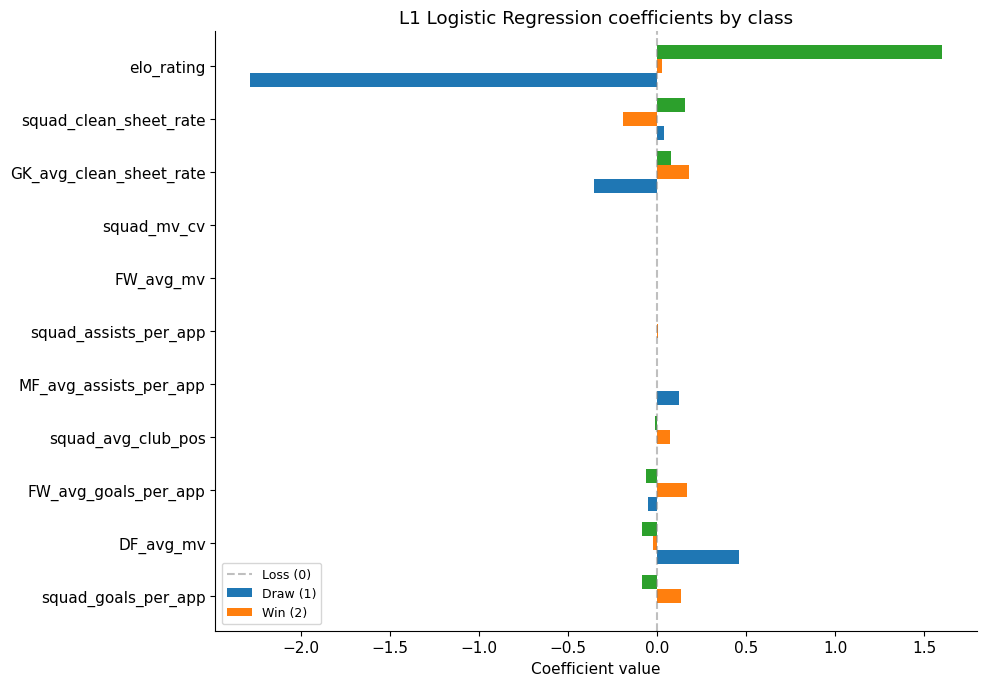

In [ ]:
# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 7))
coef_plot = coef_df.drop(columns=["abs_max"]).sort_values(
    f"coef_class_{classes[2]}", ascending=True
)
coef_plot.plot(kind="barh", ax=ax, width=0.8)
ax.set_xlabel("Coefficient value")
ax.set_title("L1 Logistic Regression coefficients by class")
ax.axvline(0, color="gray", ls="--", alpha=0.5)
ax.legend(
    [f"Loss ({classes[0]})", f"Draw ({classes[1]})", f"Win ({classes[2]})"], fontsize=9
)
plt.tight_layout()
plt.show()

## 4.5 LightGBM Comparison

Shallow tree model as a comparison point. Expected to struggle with 314 observations.

In [ ]:
try:
    import lightgbm as lgb

    lgb_results = []

    for fold_name, train_years, test_year in FOLDS:
        train = clean[clean["wc_year"].isin(train_years)]
        test = clean[clean["wc_year"] == test_year]

        if len(test) == 0:
            continue

        model = lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=2,
            min_child_samples=10,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1,
        )
        model.fit(train[feat_cols_final], train["result_enc"])

        preds = model.predict(test[feat_cols_final])
        probas = model.predict_proba(test[feat_cols_final])

        acc = accuracy_score(test["result_enc"], preds)
        f1 = f1_score(test["result_enc"], preds, average="macro")
        ll = log_loss(test["result_enc"], probas)

        lgb_results.append(
            {"fold": fold_name, "accuracy": acc, "f1_macro": f1, "log_loss": ll}
        )
        print(f"[{fold_name}] acc={acc:.3f} | f1={f1:.3f} | log_loss={ll:.3f}")
        print(f"  Predicted classes: {np.unique(preds, return_counts=True)}")

    lgb_df = pd.DataFrame(lgb_results)
    print(f"\n=== LightGBM Average ===")
    print(f"  Accuracy: {lgb_df['accuracy'].mean():.3f}")
    print(f"  F1 macro: {lgb_df['f1_macro'].mean():.3f}")
    print(f"  Log loss: {lgb_df['log_loss'].mean():.3f}")

except ImportError:
    print("LightGBM not installed. Run: pip install lightgbm")
    lgb_df = None

[2014] acc=0.556 | f1=0.409 | log_loss=1.041
  Predicted classes: (array([0, 1, 2]), array([15,  7, 23]))
[2018] acc=0.621 | f1=0.457 | log_loss=1.001
  Predicted classes: (array([0, 1, 2]), array([26,  2, 30]))
[2022] acc=0.621 | f1=0.446 | log_loss=1.139
  Predicted classes: (array([0, 1, 2]), array([24,  1, 33]))

=== LightGBM Average ===
  Accuracy: 0.599
  F1 macro: 0.437
  Log loss: 1.060


## 4.6 Draw Threshold Optimization

Instead of taking argmax of probabilities, predict a draw when the win and loss probabilities are close. Optimize the threshold on training data.

In [ ]:
def predict_with_draw_threshold(probas, classes, epsilon):
    """If |P(Win) - P(Loss)| < epsilon, predict Draw."""
    preds = []
    # Find class indices
    win_idx = list(classes).index(2)
    loss_idx = list(classes).index(0)
    draw_idx = list(classes).index(1)

    for p in probas:
        if abs(p[win_idx] - p[loss_idx]) < epsilon:
            preds.append(1)  # Draw
        else:
            preds.append(classes[np.argmax(p)])
    return np.array(preds)


# Optimize epsilon on training folds
best_eps_per_fold = {}

for fold_name, train_years, test_year in FOLDS:
    train = clean[clean["wc_year"].isin(train_years)]
    test = clean[clean["wc_year"] == test_year]

    if len(test) == 0:
        continue

    model = l1_models[fold_name]
    classes = model.named_steps["clf"].classes_

    # Optimize on training data
    train_probas = model.predict_proba(train[feat_cols_final])

    best_eps = 0
    best_f1 = 0

    for eps in np.arange(0.05, 0.50, 0.01):
        preds = predict_with_draw_threshold(train_probas, classes, eps)
        f1 = f1_score(train["result_enc"], preds, average="macro")
        if f1 > best_f1:
            best_f1 = f1
            best_eps = eps

    best_eps_per_fold[fold_name] = best_eps
    print(f"[{fold_name}] Best epsilon={best_eps:.2f} (train F1={best_f1:.3f})")

[2014] Best epsilon=0.06 (train F1=0.632)
[2018] Best epsilon=0.38 (train F1=0.572)
[2022] Best epsilon=0.09 (train F1=0.589)


In [ ]:
# Apply optimized threshold to test sets
draw_results = []

for fold_name, train_years, test_year in FOLDS:
    train = clean[clean["wc_year"].isin(train_years)]
    test = clean[clean["wc_year"] == test_year]

    if len(test) == 0:
        continue

    model = l1_models[fold_name]
    classes = model.named_steps["clf"].classes_
    eps = best_eps_per_fold[fold_name]

    probas = model.predict_proba(test[feat_cols_final])
    preds_raw = model.predict(test[feat_cols_final])
    preds_draw = predict_with_draw_threshold(probas, classes, eps)

    acc_raw = accuracy_score(test["result_enc"], preds_raw)
    acc_draw = accuracy_score(test["result_enc"], preds_draw)
    f1_raw = f1_score(test["result_enc"], preds_raw, average="macro")
    f1_draw = f1_score(test["result_enc"], preds_draw, average="macro")

    draw_results.append(
        {
            "fold": fold_name,
            "eps": eps,
            "acc_raw": acc_raw,
            "acc_draw": acc_draw,
            "f1_raw": f1_raw,
            "f1_draw": f1_draw,
            "draws_predicted_raw": (preds_raw == 1).sum(),
            "draws_predicted_thresh": (preds_draw == 1).sum(),
            "actual_draws": (test["result_enc"] == 1).sum(),
        }
    )

    print(f"[{fold_name}] eps={eps:.2f}")
    print(
        f"  Raw:       acc={acc_raw:.3f} f1={f1_raw:.3f} draws_pred={int((preds_raw == 1).sum())}"
    )
    print(
        f"  Threshold: acc={acc_draw:.3f} f1={f1_draw:.3f} draws_pred={int((preds_draw == 1).sum())}"
    )
    print(f"  Actual draws: {int((test['result_enc'] == 1).sum())}")

draw_df = pd.DataFrame(draw_results)

[2014] eps=0.06
  Raw:       acc=0.711 f1=0.485 draws_pred=2
  Threshold: acc=0.667 f1=0.480 draws_pred=6
  Actual draws: 3
[2018] eps=0.38
  Raw:       acc=0.655 f1=0.473 draws_pred=0
  Threshold: acc=0.448 f1=0.420 draws_pred=22
  Actual draws: 9
[2022] eps=0.09
  Raw:       acc=0.638 f1=0.457 draws_pred=0
  Threshold: acc=0.655 f1=0.566 draws_pred=3
  Actual draws: 9


## 4.7 Evaluation

### 4.7.1 Model Comparison

In [ ]:
# Summary table
comparison = pd.DataFrame(
    {
        "Model": ["Elo Only", "L1 LogReg", "L1 + Draw Thresh"],
        "Avg Accuracy": [
            elo_baseline["accuracy"].mean(),
            l1_df["accuracy"].mean(),
            draw_df["acc_draw"].mean(),
        ],
        "Avg F1 Macro": [
            elo_baseline["f1_macro"].mean(),
            l1_df["f1_macro"].mean(),
            draw_df["f1_draw"].mean(),
        ],
        "Avg Log Loss": [
            elo_baseline["log_loss"].mean(),
            l1_df["log_loss"].mean(),
            l1_df["log_loss"].mean(),  # same probas, different argmax
        ],
    }
)

if lgb_df is not None:
    comparison = pd.concat(
        [
            comparison,
            pd.DataFrame(
                [
                    {
                        "Model": "LightGBM (shallow)",
                        "Avg Accuracy": lgb_df["accuracy"].mean(),
                        "Avg F1 Macro": lgb_df["f1_macro"].mean(),
                        "Avg Log Loss": lgb_df["log_loss"].mean(),
                    }
                ]
            ),
        ],
        ignore_index=True,
    )

print("=== Model Comparison ===")
print(comparison.round(3).to_string(index=False))

=== Model Comparison ===
             Model  Avg Accuracy  Avg F1 Macro  Avg Log Loss
          Elo Only         0.715         0.504         0.803
         L1 LogReg         0.668         0.472         0.885
  L1 + Draw Thresh         0.590         0.489         0.885
LightGBM (shallow)         0.599         0.437         1.060


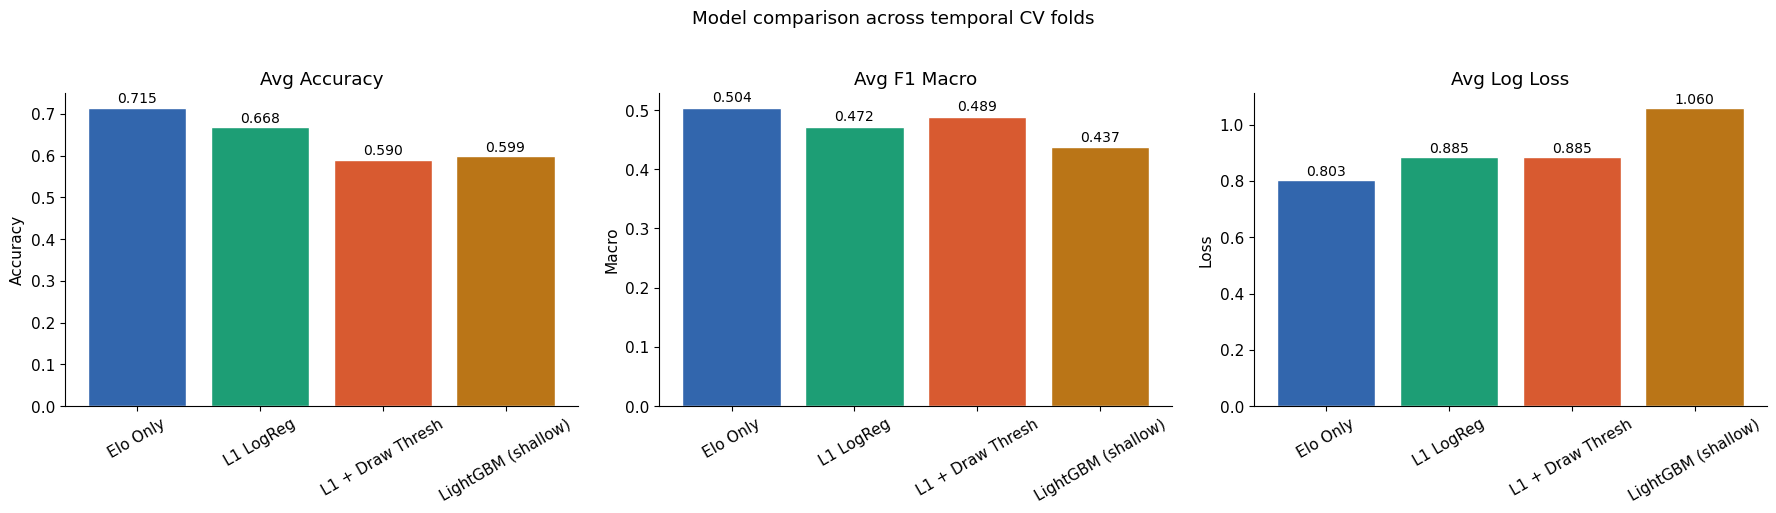

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["Avg Accuracy", "Avg F1 Macro", "Avg Log Loss"]
colors = ["#3266ad", "#1D9E75", "#D85A30", "#BA7517"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        comparison["Model"],
        comparison[metric],
        color=colors[: len(comparison)],
        edgecolor="white",
    )
    ax.set_title(metric)
    ax.set_ylabel(metric.split()[-1])
    ax.tick_params(axis="x", rotation=30)

    for bar, val in zip(bars, comparison[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.suptitle("Model comparison across temporal CV folds", y=1.02)
plt.tight_layout()
plt.show()

### 4.7.2 Confusion Matrices

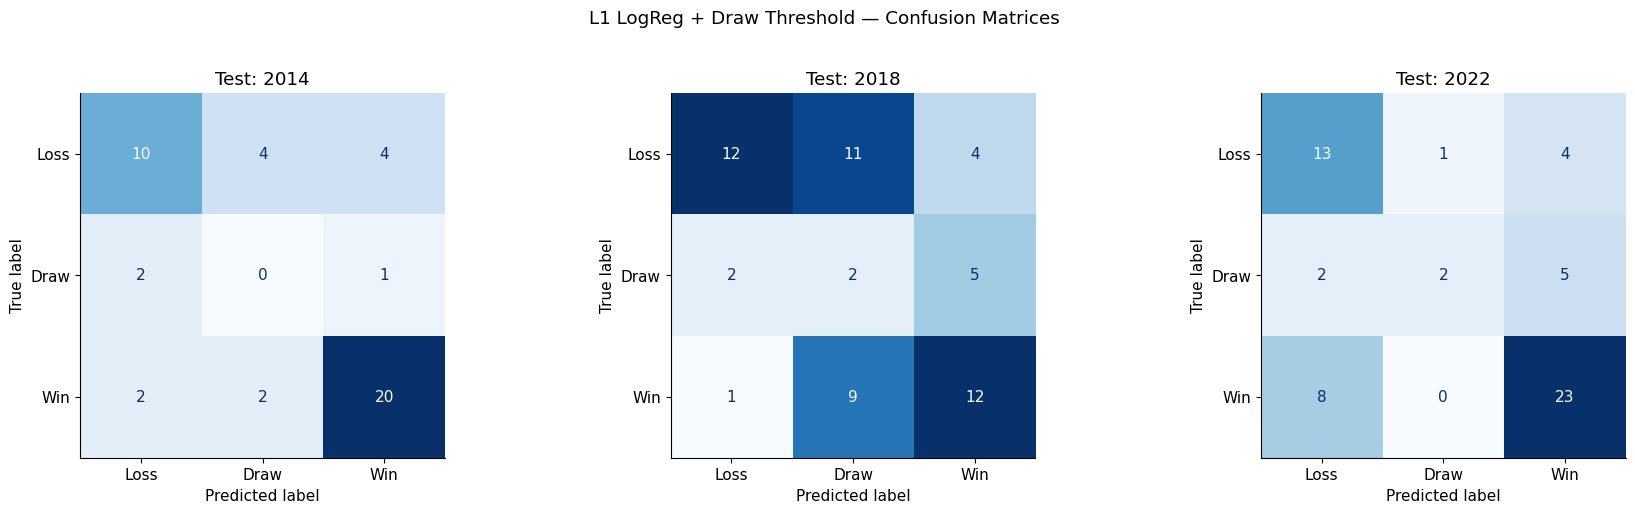

In [16]:
# Confusion matrices for each fold — L1 with draw threshold
fig, axes = plt.subplots(1, len(FOLDS), figsize=(6 * len(FOLDS), 5))
if len(FOLDS) == 1:
    axes = [axes]

for ax, (fold_name, train_years, test_year) in zip(axes, FOLDS):
    test = clean[clean["wc_year"] == test_year]
    if len(test) == 0:
        continue

    model = l1_models[fold_name]
    classes = model.named_steps["clf"].classes_
    eps = best_eps_per_fold[fold_name]

    probas = model.predict_proba(test[feat_cols_final])
    preds = predict_with_draw_threshold(probas, classes, eps)

    cm = confusion_matrix(test["result_enc"], preds, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Loss", "Draw", "Win"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Test: {fold_name}")

plt.suptitle("L1 LogReg + Draw Threshold — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

### 4.7.3 Per-Fold Breakdown

In [ ]:
# Detailed classification report for each fold
for fold_name, train_years, test_year in FOLDS:
    test = clean[clean["wc_year"] == test_year]
    if len(test) == 0:
        continue

    model = l1_models[fold_name]
    classes = model.named_steps["clf"].classes_
    eps = best_eps_per_fold[fold_name]

    probas = model.predict_proba(test[feat_cols_final])
    preds = predict_with_draw_threshold(probas, classes, eps)

    print(f"\n=== {fold_name} (test on WC-{test_year}) ===")
    print(
        classification_report(
            test["result_enc"],
            preds,
            labels=[0, 1, 2],
            target_names=["Loss", "Draw", "Win"],
            digits=3,
        )
    )


=== 2014 (test on WC-2014) ===
              precision    recall  f1-score   support

        Loss      0.714     0.556     0.625        18
        Draw      0.000     0.000     0.000         3
         Win      0.800     0.833     0.816        24

    accuracy                          0.667        45
   macro avg      0.505     0.463     0.480        45
weighted avg      0.712     0.667     0.685        45


=== 2018 (test on WC-2018) ===
              precision    recall  f1-score   support

        Loss      0.800     0.444     0.571        27
        Draw      0.091     0.222     0.129         9
         Win      0.571     0.545     0.558        22

    accuracy                          0.448        58
   macro avg      0.487     0.404     0.420        58
weighted avg      0.603     0.448     0.498        58


=== 2022 (test on WC-2022) ===
              precision    recall  f1-score   support

        Loss      0.565     0.722     0.634        18
        Draw      0.667     0.222

## 4.8 Feature Importance

In [ ]:
# Coefficient stability across folds
all_coefs = []
for fold_name, model in l1_models.items():
    clf = model.named_steps["clf"]
    classes = clf.classes_
    win_idx = list(classes).index(2)
    coefs = clf.coef_[win_idx]
    all_coefs.append(
        pd.Series(
            coefs,
            index=[c.replace("diff_", "") for c in feat_cols_final],
            name=fold_name,
        )
    )

coef_stability = pd.DataFrame(all_coefs).T
coef_stability["mean"] = coef_stability.mean(axis=1)
coef_stability["std"] = coef_stability.std(axis=1)
coef_stability = coef_stability.sort_values("mean", ascending=False)

print("=== Win-class coefficient stability across folds ===")
print(coef_stability.round(4).to_string())

=== Win-class coefficient stability across folds ===
                           2014    2018    2022    mean     std
elo_rating               0.8697  1.4391  1.6026  1.3038  0.3141
squad_clean_sheet_rate   0.1454  0.0670  0.1551  0.1225  0.0394
GK_avg_clean_sheet_rate  0.0000  0.0689  0.0792  0.0494  0.0352
squad_assists_per_app    0.1477  0.0000  0.0000  0.0492  0.0696
FW_avg_mv                0.0000  0.0000  0.0000  0.0000  0.0000
MF_avg_assists_per_app   0.0000  0.0000  0.0000  0.0000  0.0000
squad_mv_cv              0.0000  0.0000  0.0000  0.0000  0.0000
squad_avg_club_pos       0.0000 -0.0255 -0.0128 -0.0128  0.0104
FW_avg_goals_per_app     0.0000  0.0000 -0.0637 -0.0212  0.0300
DF_avg_mv                0.0000  0.0000 -0.0811 -0.0270  0.0382
squad_goals_per_app      0.0000  0.0000 -0.0837 -0.0279  0.0395


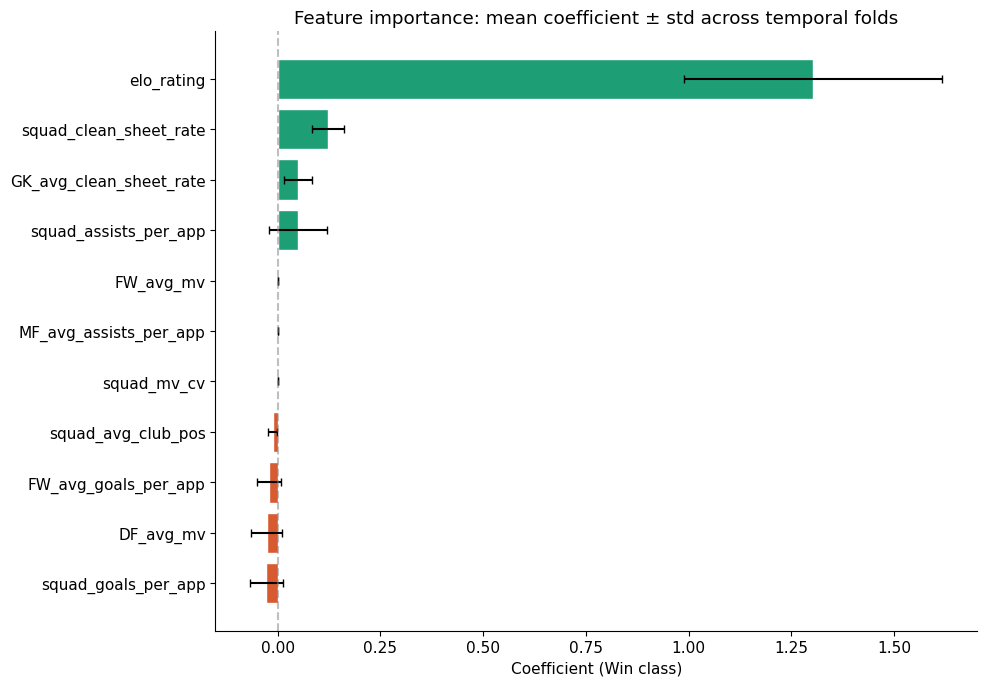

In [ ]:
# Visualize coefficient stability
fig, ax = plt.subplots(figsize=(10, 7))

y_pos = range(len(coef_stability))
ax.barh(
    y_pos,
    coef_stability["mean"],
    xerr=coef_stability["std"],
    color=["#1D9E75" if v > 0 else "#D85A30" for v in coef_stability["mean"]],
    edgecolor="white",
    capsize=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_stability.index)
ax.axvline(0, color="gray", ls="--", alpha=0.5)
ax.set_xlabel("Coefficient (Win class)")
ax.set_title("Feature importance: mean coefficient ± std across temporal folds")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4.9 Summary

*To be filled after running. Key questions:*

1. Does the player-aggregated model beat the Elo-only baseline?
2. Which features survived L1 regularization?
3. Did the draw threshold improve F1?
4. How did LightGBM compare to Logistic Regression on this dataset size?
5. Which positional features contribute most to predicting wins?